<a href="https://colab.research.google.com/github/Mohammed-Abu-Oudah/Predication-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales
- Author: Mohammed Farid AbuOwda

## Project Overview

##Load and Inspect Data

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
sales_df = pd.read_csv(fpath)

In [3]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [4]:
sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


##Clean Data

In [5]:
# How many rows
print(len(sales_df))
# How many columns
print(len(sales_df.columns))

8523
12


In [6]:
sales_df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [7]:
# Are there any Duplicates? No
sales_df.duplicated().sum()

np.int64(0)

In [8]:
# Identify Missing Values.
sales_df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [9]:
sales_df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [10]:
# Fill missing values with placeholders.
sales_df['Item_Weight'] = sales_df['Item_Weight'].fillna(-1)
print(f'number of missing values in item weight {sales_df['Item_Weight'].isna().sum()}')
sales_df['Outlet_Size'] = sales_df['Outlet_Size'].fillna('MISSING')
print(f'number of missing values in outlet size {sales_df['Outlet_Size'].isna().sum()}')

number of missing values in item weight 0
number of missing values in outlet size 0


<Axes: >

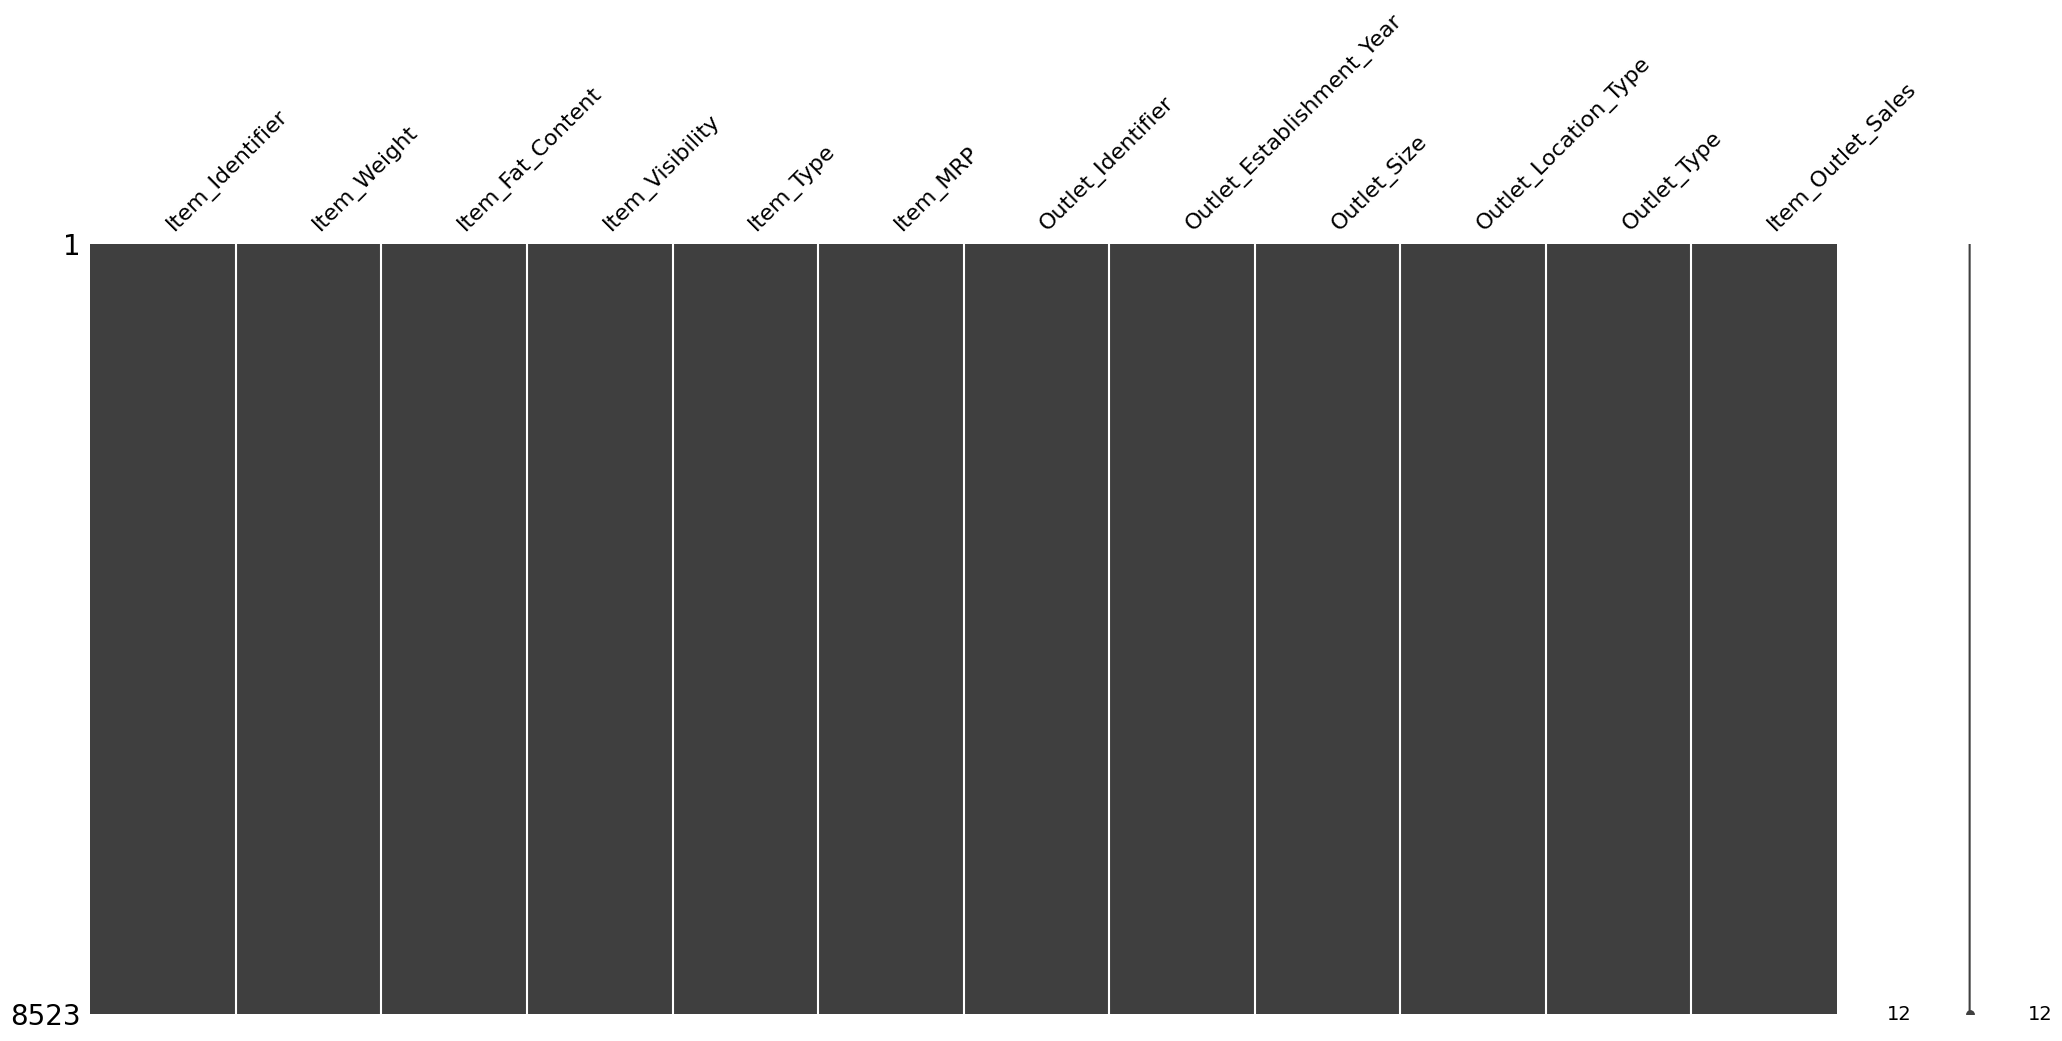

In [11]:
import missingno as msno
msno.matrix(sales_df)

In [12]:
# Fix inconsistant data: first we need to check if any inconsistant data exist
cat_columns = sales_df.select_dtypes('object')
for column in cat_columns:
  print(sales_df[column].value_counts())
  print("\n")

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: cou

In [13]:
# We can notice that in the Item_Fat_Content we find an inconsistent data in both low fat and regular
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].replace({"LF" : "Low Fat", "low fat" : "Low Fat", "reg": "Regular"})
sales_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [14]:
sales_df.describe().round()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.0,8523.0,8523.0,8523.0,8523.0
mean,10.0,0.0,141.0,1998.0,2181.0
std,7.0,0.0,62.0,8.0,1706.0
min,-1.0,0.0,31.0,1985.0,33.0
25%,7.0,0.0,94.0,1987.0,834.0
50%,11.0,0.0,143.0,1999.0,1794.0
75%,16.0,0.0,186.0,2004.0,3101.0
max,21.0,0.0,267.0,2009.0,13087.0


##Exploratory Data Analysis

##Feature Inspection

**Now let's visualize the to understand the different relations**

In [15]:
# First, get the info to show the features we need to work on
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [16]:
# Ok now lets descibe the numerical data using Histograms
# First let's list the numerical columns
numeric_cols = sales_df.select_dtypes('number').columns.tolist()
numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [17]:
# Ok, so for every one of the above, we will draw the histogram to understand the distribution of the data.
# But first let's import the seaborn and matplotlib libraries
import seaborn as sns
import matplotlib.pyplot as plt

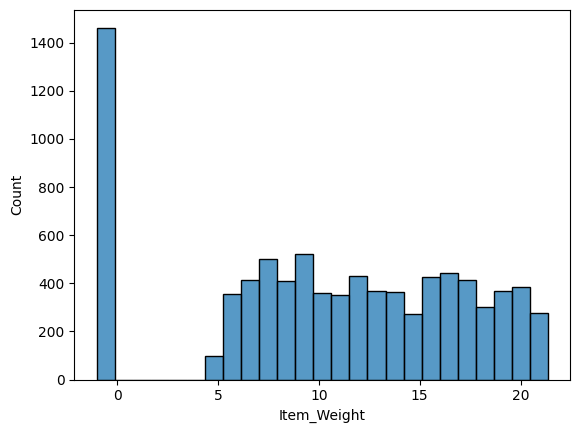

In [18]:
# Print the historgram for Item_Weight
sns.histplot(data=sales_df, x='Item_Weight');

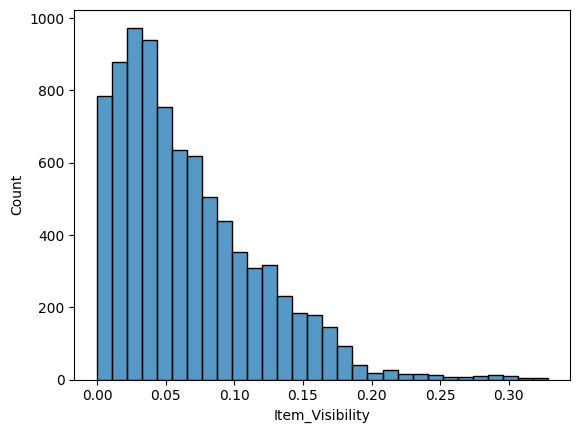

In [19]:
# We can notice that the highest number of weights is -1 due to us replacing the Nan value with -1
# Now let's move on to the Item_Visibility column
sns.histplot(data=sales_df, x='Item_Visibility', bins=30);

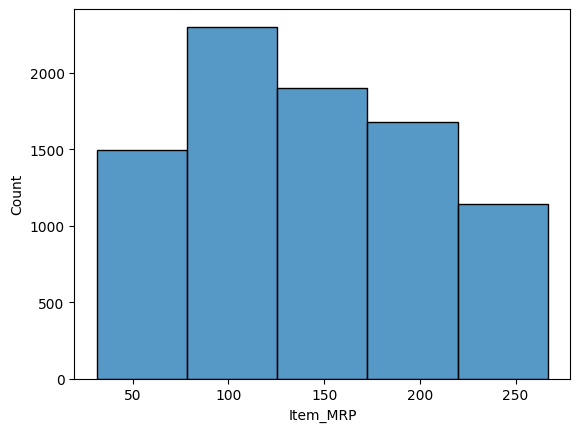

In [20]:
# We can notice that the Item_Visibility doesn't follow a normal distribution (it is right skewed)
# Now let's plot the Item_MRP column
sns.histplot(data=sales_df, x='Item_MRP', bins=5);

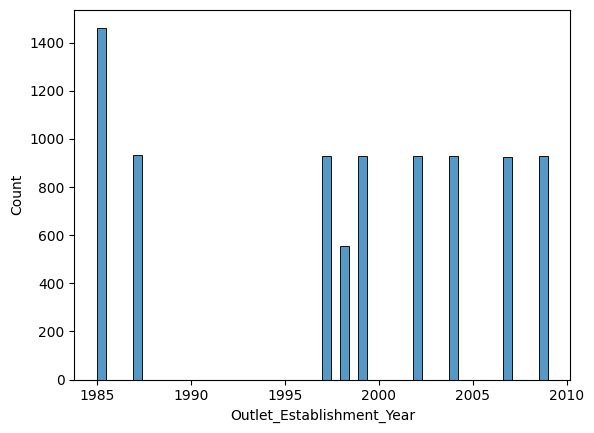

In [21]:
# We can notic that the Item_MRP data doesn't have a specific pattern for the data distribution with a big number of bins but starts to follow right skewed Gaussian ditribution
# when reducing the number of bins.
# Now let's move to the Outlet_Establishment_Year column
sns.histplot(data=sales_df, x='Outlet_Establishment_Year', bins=50);

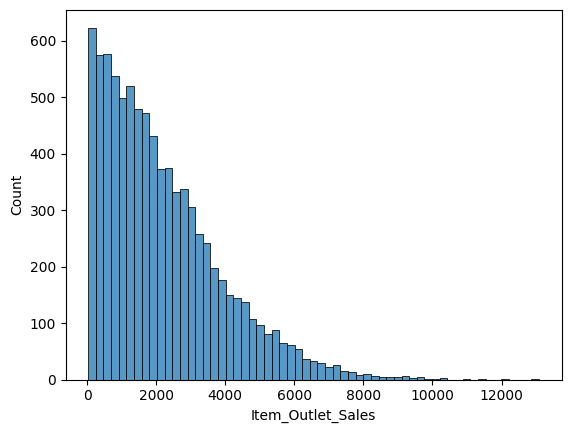

In [22]:
# We can notice that most of the outlet's were established between years 1998 and 2000 and years 1985 and 1987
# And with the number of bins reduced, the data doesn't follow any Gaussian distribution.
# When increasing th number of bins we can notice that the highest number of outlets established - was in year 1985 - 1986
# that could be to the fact that in this period, the transition from small grocery to the big supermarkets and the big supermaket brands started to show up.
# Now let's move the Item_Outlet_Sales column
sns.histplot(data=sales_df, x='Item_Outlet_Sales');

In [23]:
# We can notice that the Item_Outlet_Sales follow a right skewed Gaussian distribution
# most of the Item_Outlet_Sales are concentrated bewteen 0 and 2000, that could be to the fact that we might have a big number of small super markets emerging.
# Ok now let's move on to draw box plots for our numeric data
# same order as before but this time we will plot some boxplots
numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [24]:
# To save time we can just plot all the box plots in one plot to get an over new of the columns that has outliers
numeric_df = sales_df.select_dtypes('number')
numeric_df

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.300,0.016047,249.8092,1999,3735.1380
1,5.920,0.019278,48.2692,2009,443.4228
2,17.500,0.016760,141.6180,1999,2097.2700
3,19.200,0.000000,182.0950,1998,732.3800
4,8.930,0.000000,53.8614,1987,994.7052
...,...,...,...,...,...
8518,6.865,0.056783,214.5218,1987,2778.3834
8519,8.380,0.046982,108.1570,2002,549.2850
8520,10.600,0.035186,85.1224,2004,1193.1136
8521,7.210,0.145221,103.1332,2009,1845.5976


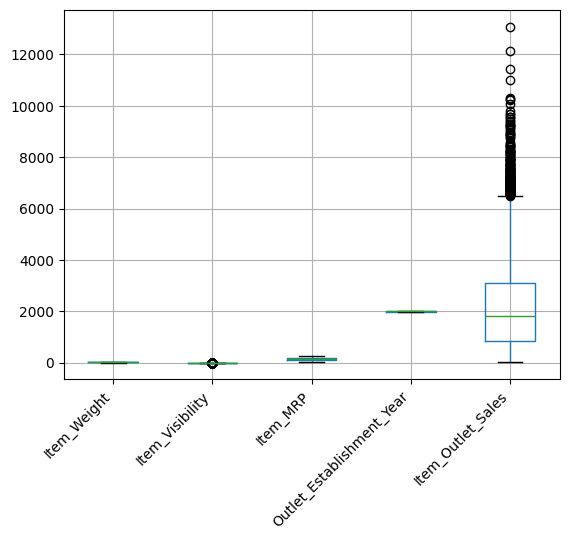

In [25]:
fig, ax = plt.subplots()
ax = numeric_df.boxplot()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

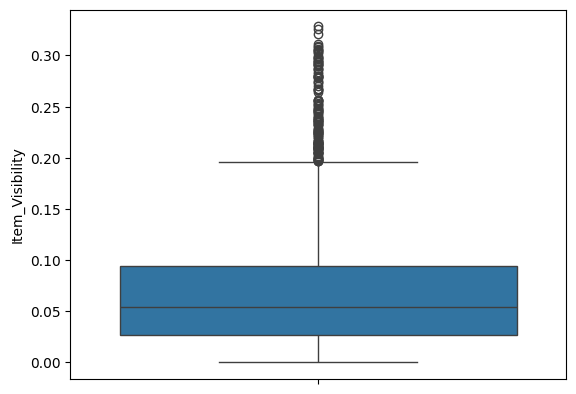

In [26]:
# Both Item_Visiblity and Item_Outlet_Sales have outliers, for that we will try to draw them on a seperate plots
# Now let's draw the Item_Visiblity
sns.boxplot(sales_df, y='Item_Visibility');

<Axes: ylabel='Item_Outlet_Sales'>

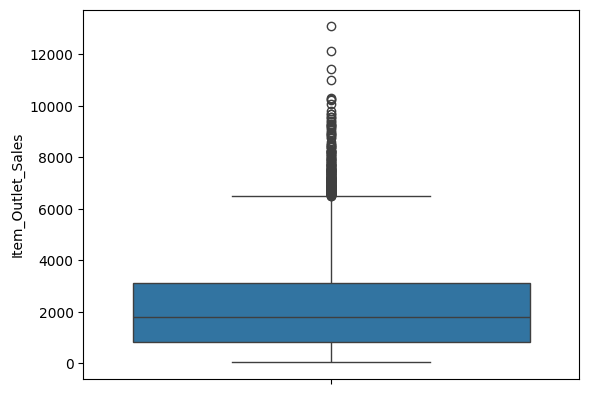

In [27]:
# We can notice that the item visibility has a segnificant number of outliers, this could be due the way of shelfing the products.
# Now let's move to the Item_Outlet_Sales boxplot
sns.boxplot(data=sales_df, y='Item_Outlet_Sales')

In [28]:
# We can also see that the Item_Outlet_Sales has a segnificant number of outliers due to the facts that some of these items exist in big and famous markets, and some good are consumed more than others.

<Axes: >

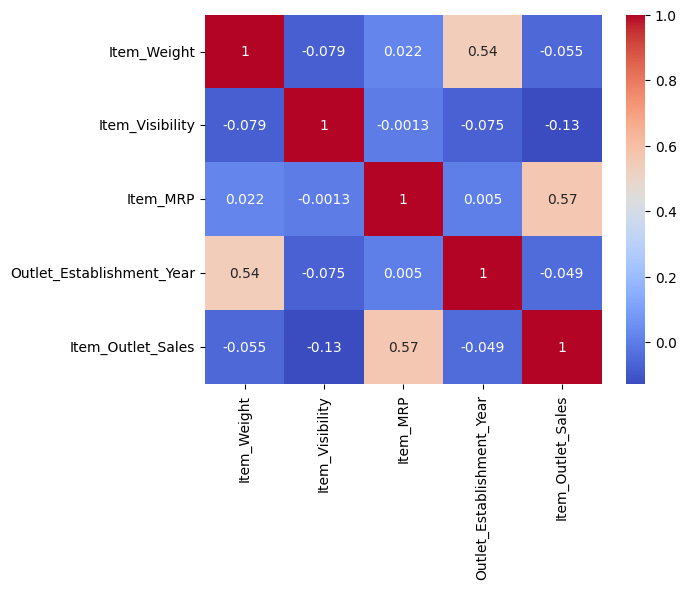

In [29]:
# Now befor moving to the categorical columns, let's draw a heatmap of the numeric columns
corr = sales_df.corr(numeric_only=True)
sns.heatmap(data=corr, cmap='coolwarm', annot=True)

In [30]:
# We can notic an intermediate relationship between (item weight, outlet establishment year) and (outlet establishment year, item MRP) couples.

**Now let's work with the categorical data**

In [31]:
# First we will extract the columns of the categorical data
cat_columns.columns.tolist()

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

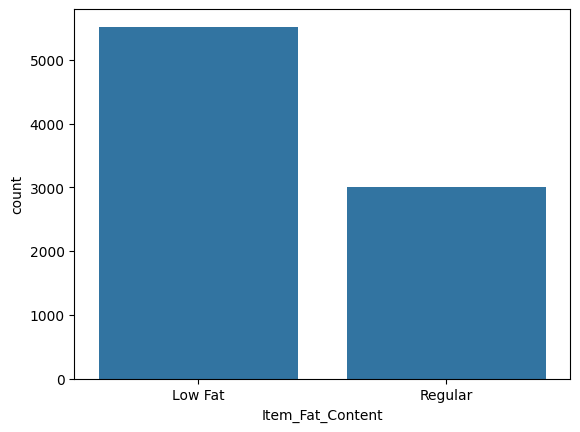

In [32]:
# First Item_Identifier, we can't make count plot for that due to the huge number of items out there.
# Second Item_Fat_Content
sns.countplot(data=sales_df, x='Item_Fat_Content');

/tmp/ipykernel_906/1051979962.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


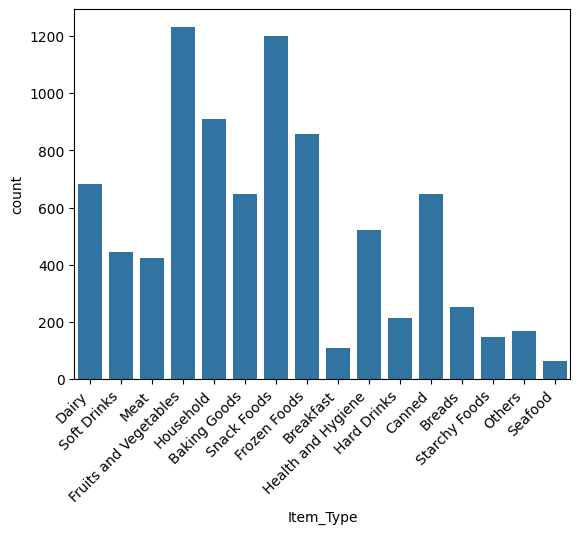

In [33]:
# We can notice that the Items with low fats have higher counts the regular.
# Third Item_Type
ax = sns.countplot(data=sales_df, x='Item_Type');
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

/tmp/ipykernel_906/2138505694.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


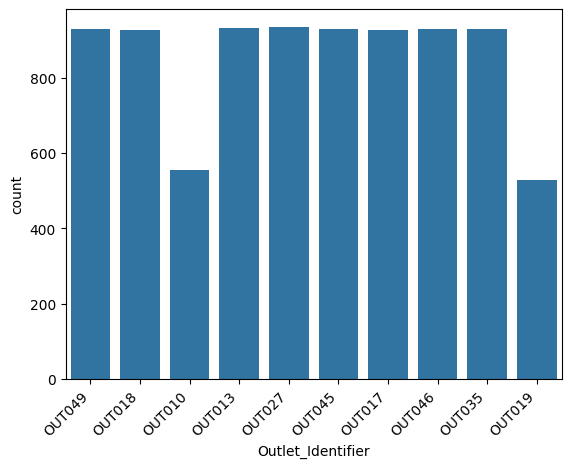

In [36]:
# The Fruits and Vegetables are the items with the highest number of sales.
# now Outlet_Identifier has now meaning to graph the countplot for, but we will keep it in case we wanted to see how much did a specific outlet got repeated.
ax = sns.countplot(data=sales_df, x='Outlet_Identifier');
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

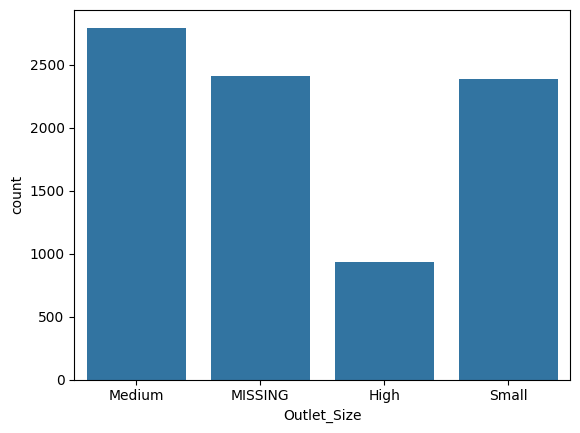

In [37]:
# Now let's draw the countplot for Outlet_Size
ax = sns.countplot(data=sales_df, x='Outlet_Size');

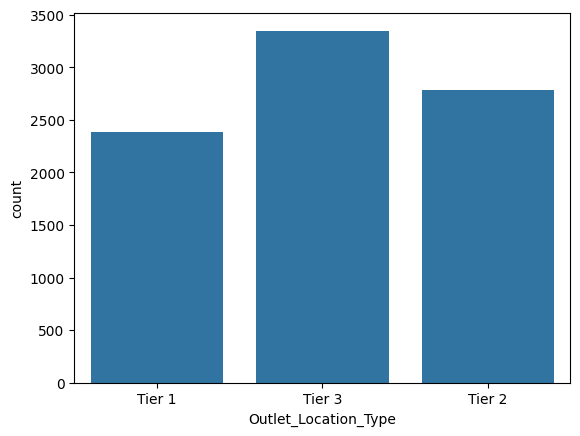

In [38]:
# We can notice that the highest number of outlets are the medium ones.
# Now let's go for Outlet_Location_Type
ax = sns.countplot(data=sales_df, x='Outlet_Location_Type');

/tmp/ipykernel_906/3509958554.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


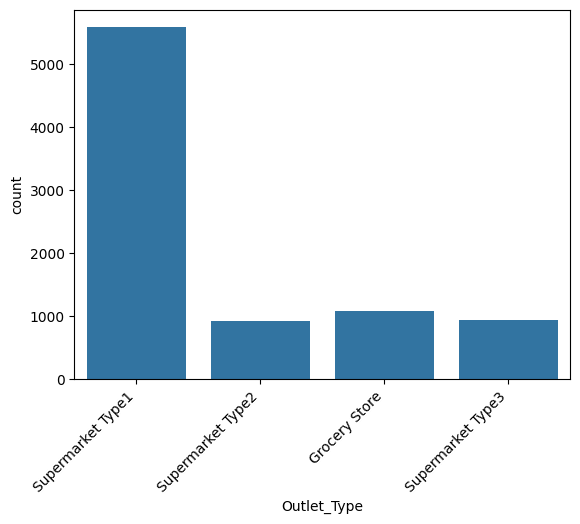

In [40]:
# The highest number of the outlet location type is 'Tier 3'
# Now Outlet_Type
ax = sns.countplot(data=sales_df, x='Outlet_Type');
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

In [ ]:
# the Outlet type with the highest number is Supermarket Type1